In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns


Data Validation

In [2]:
df = pd.read_csv(r'C:\Users\Vidhi\OneDrive\Desktop\Python - Project\customer_model_base.csv')
print("Shapes: ", df.shape)
print("Coloumn types: ", df.dtypes)
print("Null values: ", df.isnull().sum())
print('First 5 rows: ')
df.head()

Shapes:  (115715, 8)
Coloumn types:  order_id           object
customer_id        object
order_date         object
order_value       float64
payment_value     float64
customer_city      object
customer_state     object
review_score      float64
dtype: object
Null values:  order_id            0
customer_id         0
order_date          0
order_value         0
payment_value       3
customer_city       0
customer_state      0
review_score      861
dtype: int64
First 5 rows: 


,order_id,customer_id,order_date,order_value,payment_value,customer_city,customer_state,review_score
0,fd26702a3f7ee5d86580de591ff53e3f,d3b1dd5a9cafa5e8191a28f92a8f5d40,2017-07-04,56.420000,56.42,santa rosa de lima,SC,5.0
1,fe642627ef34edffd9e897365f2d0449,41c81db0288d706cbb0937bddbea8f95,2018-04-16,31.870000,63.74,sao paulo,SP,4.0
2,fe642627ef34edffd9e897365f2d0449,41c81db0288d706cbb0937bddbea8f95,2018-04-16,31.870000,63.74,sao paulo,SP,4.0
3,aee1ebae09f6d91ca6a459bf47b14072,07cc6026f1fba9869ce6efc681fd190d,2018-04-10,121.700001,121.70,nova lima,MG,5.0
4,800d19e2eed430cbd8e9bcb12087794b,f222c3229196dc3b016502cbd1ad6cfc,2018-08-13,36.940000,36.94,sao paulo,SP,5.0


Data Cleaning 

In [3]:
df['order_date'] = pd.to_datetime(df['order_date'])

df = df[df['order_value']>0]

print(df['order_value'].describe())

upper_limit = df['order_value'].quantile(0.99)
df = df[df['order_value'] > upper_limit ]

print('Clean dataset shape', df.shape)
print('Date Range: ', df['order_date'].min(), 'to ', df['order_date'].max())

count    115715.000000
mean        139.890250
std         189.727660
min           6.080000
25%          55.220001
50%          91.790002
75%         157.219999
max        6929.309998
Name: order_value, dtype: float64
Clean dataset shape (1157, 8)
Date Range:  2016-10-04 00:00:00 to  2018-08-26 00:00:00


RFM Calculation: Performed RFM (Recency, Frequency, Monetary) analysis to evaluate customer purchasing behavior and segment customers based on activity, loyalty, and spending patterns.

This helps identify loyal, high-value, and at-risk customers for retention and marketing strategy optimization.

In [4]:
# Snapshot date = 1 day after last order (simulates "today")
snapshot_date = df['order_date'].max() + pd.Timedelta(days=1)

rfm = df.groupby('customer_id').agg(
    Recency   = ('order_date',  lambda x: (snapshot_date - x.max()).days),
    Frequency = ('order_id',    'count'),
    Monetary  = ('order_value', 'sum')
).reset_index()

print(rfm.describe())
rfm.head()

           Recency    Frequency      Monetary
count  1056.000000  1056.000000   1056.000000
mean    242.013258     1.095644   1621.979812
std     158.807576     0.497710    979.068817
min       1.000000     1.000000    923.260000
25%     109.000000     1.000000   1093.325003
50%     223.000000     1.000000   1327.900021
75%     360.000000     1.000000   1839.565002
max     692.000000     8.000000  13664.080002


,customer_id,Recency,Frequency,Monetary
0,000598caf2ef4117407665ac33275130,16,1,1255.710007
1,00205ad9ba1ef4340cef86583294cf82,107,1,928.700024
2,0049e8442c2a3e4a8d1ff5a9549abd53,364,2,2501.620003
3,005196c65bab2861e397cc85bc7664bf,222,1,1233.649994
4,00c634fb2feeb4e2767a916c2375c9b8,7,1,1318.060024


Score each RFM dimension

In [5]:
# Score 1-4 (4 = best for F and M, 4 = most recent for R)
rfm['R_score'] = pd.qcut(rfm['Recency'],
                          q=4, labels=[4, 3, 2, 1])  # reversed: low recency = good

rfm['F_score'] = pd.qcut(rfm['Frequency'].rank(method='first'),
                          q=4, labels=[1, 2, 3, 4])

rfm['M_score'] = pd.qcut(rfm['Monetary'],
                          q=4, labels=[1, 2, 3, 4])

# Total RFM score
rfm['RFM_score'] = (rfm['R_score'].astype(int) +
                    rfm['F_score'].astype(int) +
                    rfm['M_score'].astype(int))

print(rfm['RFM_score'].value_counts().sort_index())

RFM_score
3      19
4      67
5      91
6     167
7     182
8     196
9     153
10     98
11     44
12     39
Name: count, dtype: int64


Assign segments

In [6]:
def assign_segment(row):
    r = int(row['R_score'])
    f = int(row['F_score'])
    score = row['RFM_score']
    
    if score >= 10:
        return 'Champions'
    elif score >= 7:
        return 'Loyal'
    elif r <= 2 and f >= 3:
        return 'At Risk'
    elif r <= 2:
        return 'Churned'
    else:
        return 'Promising'

rfm['Segment'] = rfm.apply(assign_segment, axis=1)

print(rfm['Segment'].value_counts())

Segment
Loyal        531
Churned      201
Champions    181
Promising     77
At Risk       66
Name: count, dtype: int64


Cohort retention: D2C synthetic data for the cohort table

In [7]:
# Realistic cohort retention for a D2C beauty brand
# Row = cohort month, Column = months after first purchase
np.random.seed(42)

cohorts = pd.period_range('2017-01', periods=12, freq='M')
max_months = 6

rows = []
for i, cohort in enumerate(cohorts):
    # Each cohort starts at 100%
    # Retention drops sharply after month 0 then stabilises
    base_retention = [100, 
                      round(np.random.uniform(28, 38), 1),
                      round(np.random.uniform(18, 26), 1),
                      round(np.random.uniform(12, 18), 1),
                      round(np.random.uniform(8,  14), 1),
                      round(np.random.uniform(6,  10), 1)]
    
    # Later cohorts retain slightly better (simulates business improvement)
    improvement = i * 0.3
    row = [cohort.strftime('%Y-%m')] + [
        min(100, round(v + improvement, 1)) if j > 0 else v 
        for j, v in enumerate(base_retention)
    ]
    rows.append(row)

cohort_synthetic = pd.DataFrame(rows, 
    columns=['cohort_month', 'Month 0', 'Month 1', 
             'Month 2', 'Month 3', 'Month 4', 'Month 5'])

cohort_synthetic.to_csv('cohort_retention.csv', index=False)
print(cohort_synthetic)

   cohort_month  Month 0  Month 1  Month 2  Month 3  Month 4  Month 5
0       2017-01      100     31.7     25.6     16.4     11.6      6.6
1       2017-02      100     29.9     18.8     17.5     11.9      9.1
2       2017-03      100     28.8     26.4     17.6      9.9      7.3
3       2017-04      100     30.7     21.3     16.0     11.5      8.1
4       2017-05      100     35.3     20.3     15.0     11.4      9.0
5       2017-06      100     37.4     21.1     16.6     13.1      7.7
6       2017-07      100     35.9     21.2     14.2     15.5     11.7
7       2017-08      100     38.2     22.5     14.7     14.2      9.9
8       2017-09      100     31.6     24.4     14.6     15.9      9.4
9       2017-10      100     37.3     23.2     17.8     14.0      9.4
10      2017-11      100     40.7     27.2     20.6     16.4     11.4
11      2017-12      100     40.5     22.0     16.5     11.6     10.6


CLV estimate

In [8]:
clv = df.groupby('customer_id').agg(
    avg_order_value = ('order_value', 'mean'),
    purchase_freq   = ('order_id',    'count')
).reset_index()

# Simple CLV: avg order value × frequency
# In a real setting you'd multiply by expected customer lifespan
clv['CLV_estimate'] = clv['avg_order_value'] * clv['purchase_freq']

# Merge RFM + CLV into one final table
final_df = rfm.merge(clv, on='customer_id')

print(final_df.shape)
final_df.head()

(1056, 12)


,customer_id,Recency,Frequency,Monetary,R_score,F_score,M_score,RFM_score,Segment,avg_order_value,purchase_freq,CLV_estimate
0,000598caf2ef4117407665ac33275130,16,1,1255.710007,4,1,2,7,Loyal,1255.710007,1,1255.710007
1,00205ad9ba1ef4340cef86583294cf82,107,1,928.700024,4,1,1,6,Promising,928.700024,1,928.700024
2,0049e8442c2a3e4a8d1ff5a9549abd53,364,2,2501.620003,1,4,4,9,Loyal,1250.810001,2,2501.620003
3,005196c65bab2861e397cc85bc7664bf,222,1,1233.649994,3,1,2,6,Promising,1233.649994,1,1233.649994
4,00c634fb2feeb4e2767a916c2375c9b8,7,1,1318.060024,4,1,2,7,Loyal,1318.060024,1,1318.060024


Quick Visualization

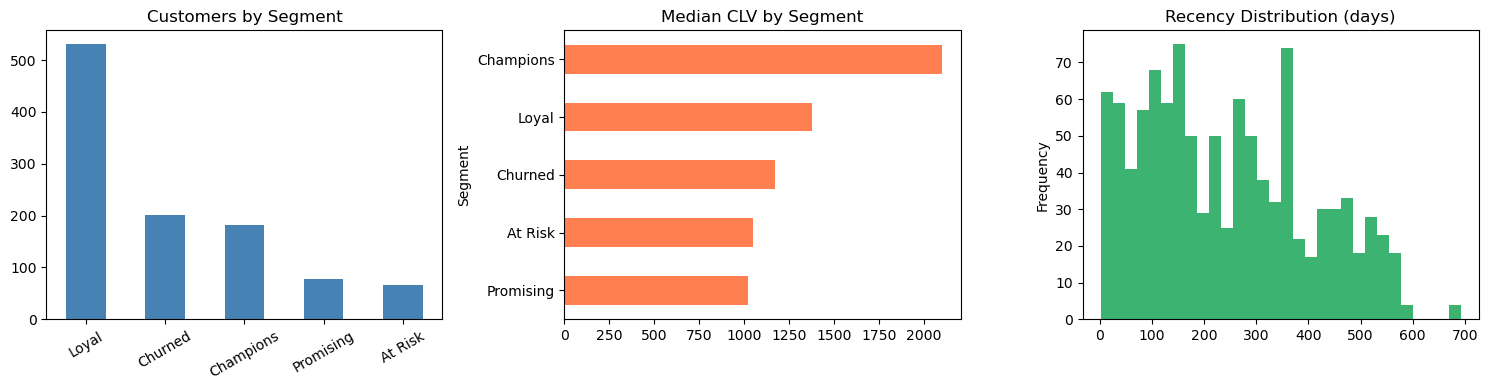

In [15]:
fig, axes = plt.subplots(1, 3, figsize=(15, 4))

# Segment distribution
rfm['Segment'].value_counts().plot(kind='bar', ax=axes[0], color='steelblue')
axes[0].set_title('Customers by Segment')
axes[0].set_xlabel('')
axes[0].tick_params(axis='x', rotation=30)

# CLV by segment
final_df.groupby('Segment')['CLV_estimate'].median().sort_values().plot(
    kind='barh', ax=axes[1], color='coral')
axes[1].set_title('Median CLV by Segment')

# Recency distribution
rfm['Recency'].plot(kind='hist', bins=30, ax=axes[2], color='mediumseagreen')
axes[2].set_title('Recency Distribution (days)')

plt.tight_layout()
plt.savefig('segment_overview.png', dpi=150)  # save for your documentation
plt.show()

Export for PowerBI

In [16]:
# Main analytics table
final_df.to_csv('customer_analytics.csv', index=False)

print("Exported:")
print(f"  customer_analytics.csv — {final_df.shape[0]} rows, {final_df.shape[1]} columns")

Exported:
  customer_analytics.csv — 1056 rows, 12 columns
  cohort_retention.csv — 21 cohorts, 1 months


In [17]:
# Export master orders for Power BI time-based visuals
df[['customer_id', 'order_date', 'order_value', 
    'customer_city', 'customer_state', 'review_score']].to_csv('orders_clean.csv', index=False)

print("Exported orders_clean.csv")

Exported orders_clean.csv
